# Customer Segmentation using K-Means Clustering (Unsupervised Learning)

This project uses unsupervised machine learning to segment customers based on their income and spending behavior.

The goal is to identify distinct customer groups and generate business insights that can support targeted marketing and customer retention strategies.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Data Generation

Since no dataset is provided, we generate a synthetic dataset representing customer income and spending behavior.

In [9]:
np.random.seed(42)

df = pd.DataFrame({
    "CustomerID": range(1, 201),
    "AnnualIncome": np.random.randint(20000, 120000, 200),
    "SpendingScore": np.random.randint(1, 100, 200)
})

df.head()

,CustomerID,AnnualIncome,SpendingScore
0,1,35795,96
1,2,20860,88
2,3,96820,52
3,4,74886,62
4,5,26265,58


## Data Exploration

We visualize the relationship between annual income and spending score to observe patterns in customer behavior.

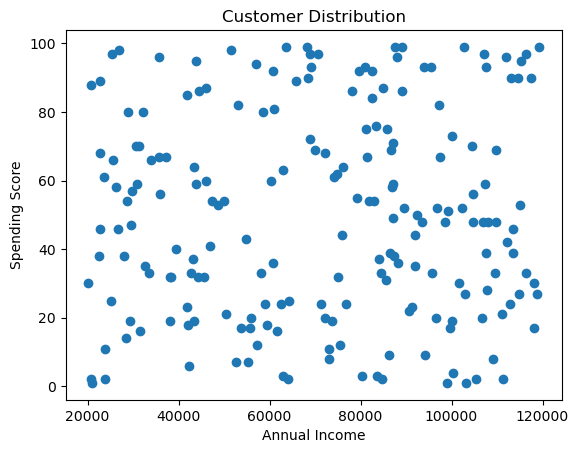

In [3]:
plt.scatter(df["AnnualIncome"], df["SpendingScore"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

## Feature Scaling

We scale the features to ensure that income and spending contribute equally to the clustering algorithm.

In [4]:
X = df[["AnnualIncome", "SpendingScore"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Determining Optimal Number of Clusters

We use the elbow method to determine the appropriate number of clusters for K-Means.

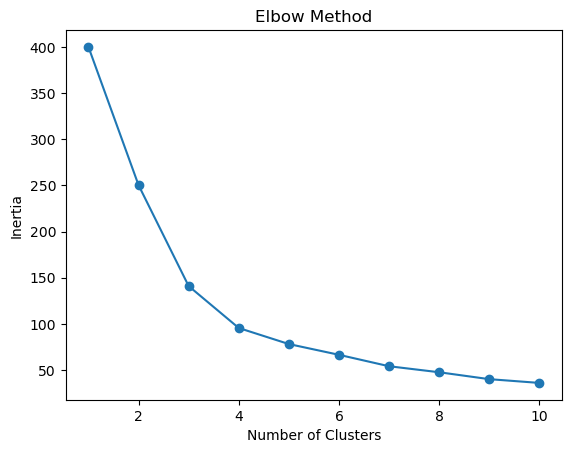

In [5]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## K-Means Clustering

Based on the elbow method, we apply K-Means clustering to segment customers.

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

## Cluster Visualization

We visualize the identified customer segments using a scatter plot.

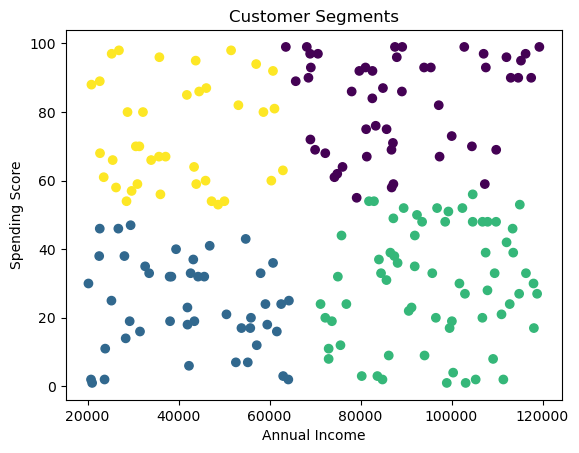

In [7]:
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=df["Cluster"], cmap='viridis')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

## Cluster Insights

The clustering results reveal four distinct customer segments based on income and spending behavior:

- Cluster 0: High income, high spending → premium / high-value customers  
- Cluster 1: Moderate income, low spending → low engagement customers  
- Cluster 2: High income, low spending → underutilized customers with potential for growth  
- Cluster 3: Lower income, high spending → frequent or impulsive buyers  

These segments highlight opportunities for targeted marketing strategies. For example, high-income low-spending customers may benefit from personalized promotions, while high-value customers should be prioritized for retention.

## Cluster Interpretation

We interpret each cluster by comparing average income and spending behavior. This helps translate the clustering results into business-relevant customer segments.

In [13]:
cluster_summary = df.groupby("Cluster")[["AnnualIncome", "SpendingScore"]].mean()
cluster_summary.sort_index()

,AnnualIncome,SpendingScore
Cluster,,
0,88877.460000,82.620000
1,42505.391304,23.739130
2,96310.348485,29.681818
3,39630.052632,73.526316


## Cluster Visualization with Labels

This visualization shows customer segments based on annual income and spending score, with each color representing a different cluster.

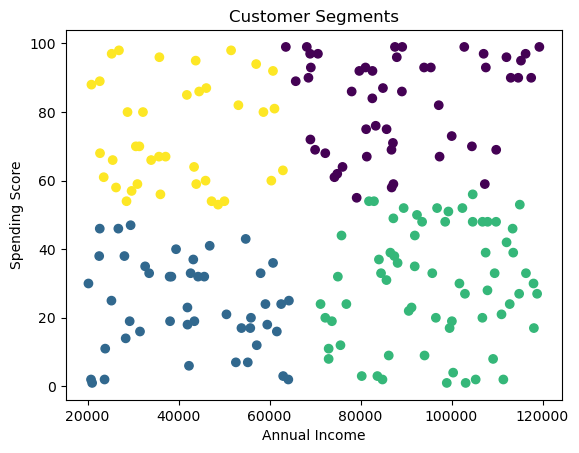

In [14]:
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=df["Cluster"], cmap="viridis")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

## Business Insights

The clustering analysis suggests that customers can be divided into distinct groups based on purchasing behavior. Some clusters may represent high-value customers with strong spending patterns, while others may represent lower-engagement or underutilized customer groups.

These results can help businesses tailor marketing strategies, improve targeting, and allocate retention efforts more effectively.

## Conclusion

This project applied K-Means clustering to segment customers using annual income and spending score. The results showed that unsupervised learning can reveal meaningful patterns in customer behavior without requiring a target variable.

Customer segmentation can support more personalized marketing, better customer relationship management, and more efficient business decision-making.